#**Laboratorul 7**

Exercitiul 1



1.   We can improve the single-shot multibox detection by improving the loss function. Replace the $\ell_1$ norm loss with the *smooth $\ell_1$ norm loss* for the predicted offsets. This loss function uses a square function around zero for smoothness, which is controlled by the hyperparameter $\sigma$:
  $$
  f(x) =
      \begin{cases}
      (\sigma x)^2/2,& \textrm{if }|x| < 1/\sigma^2\\
      |x|-0.5/\sigma^2,& \textrm{otherwise}
      \end{cases}
  $$

  When $\sigma$ is very large, this loss is similar to the $\ell_1$ norm loss. When its value is smaller, the loss function is smoother.

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import pandas as pd
import os
import requests
import zipfile

torch.manual_seed(42);

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

In [ ]:
def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    else:
        assert False, 'Only zip files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def set_figsize(figsize=(3.5, 2.5)):
    """Set the figure size for matplotlib."""
    plt.rcParams['figure.figsize'] = figsize

In [ ]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    show_images(Y, num_rows, num_cols, scale=scale)

In [ ]:
def box_corner_to_center(boxes):
    """Convert from (upper-left, lower-right) to (center, width, height)."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes

def box_center_to_corner(boxes):
    """Convert from (center, width, height) to (upper-left, lower-right)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

In [ ]:
def bbox_to_rect(bbox, color):
    """Convert bounding box to matplotlib format."""
    # Convert the bounding box (upper-left x, upper-left y, lower-right x,
    # lower-right y) format to the matplotlib format: ((upper-left x,
    # upper-left y), width, height)
    return plt.Rectangle(
        xy=(bbox[0], bbox[1]), width=bbox[2]-bbox[0], height=bbox[3]-bbox[1],
        fill=False, edgecolor=color, linewidth=2)

In [ ]:
def multibox_prior(data, sizes, ratios):
    """Generate anchor boxes with different shapes centered on each pixel."""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1)
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)
    # Offsets are required to move the anchor to the center of a pixel. Since
    # a pixel has height=1 and width=1, we choose to offset our centers by 0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # Scaled steps in y axis
    steps_w = 1.0 / in_width  # Scaled steps in x axis

    # Generate all center points for the anchor boxes
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # Generate `boxes_per_pixel` number of heights and widths that are later
    # used to create anchor box corner coordinates (xmin, xmax, ymin, ymax)
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),
                   sizes[0] * torch.sqrt(ratio_tensor[1:])))\
                   * in_height / in_width  # Handle rectangular inputs
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))
    # Divide by 2 to get half height and half width
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                        in_height * in_width, 1) / 2

    # Each center point will have `boxes_per_pixel` number of anchor boxes, so
    # generate a grid of all anchor box centers with `boxes_per_pixel` repeats
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(boxes_per_pixel, dim=0)
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)

In [ ]:
def show_bboxes(axes, bboxes, labels=None, colors=None):
    """Show bounding boxes."""

    def make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = make_list(labels)
    colors = make_list(colors, ['b', 'g', 'r', 'm', 'c'])
    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w'
            axes.text(rect.xy[0], rect.xy[1], labels[i],
                      va='center', ha='center', fontsize=9, color=text_color,
                      bbox=dict(facecolor=color, lw=0))

In [ ]:
def box_iou(boxes1, boxes2):
    """Compute pairwise IoU across two lists of anchor or bounding boxes."""
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))
    # Shape of `boxes1`, `boxes2`, `areas1`, `areas2`: (no. of boxes1, 4),
    # (no. of boxes2, 4), (no. of boxes1,), (no. of boxes2,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    # Shape of `inter_upperlefts`, `inter_lowerrights`, `inters`: (no. of
    # boxes1, no. of boxes2, 2)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    # Shape of `inter_areas` and `union_areas`: (no. of boxes1, no. of boxes2)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas
    return inter_areas / union_areas

In [ ]:
def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """Assign closest ground-truth bounding boxes to anchor boxes."""
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    # Element x_ij in the i-th row and j-th column is the IoU of the anchor
    # box i and the ground-truth bounding box j
    jaccard = box_iou(anchors, ground_truth)
    # Initialize the tensor to hold the assigned ground-truth bounding box for
    # each anchor
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,
                                  device=device)
    # Assign ground-truth bounding boxes according to the threshold
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    box_j = indices[max_ious >= iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)  # Find the largest IoU
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx / num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
    return anchors_bbox_map

In [ ]:
def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """Transform for anchor box offsets."""
    c_anc = box_corner_to_center(anchors)
    c_assigned_bb = box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset

In [ ]:
def multibox_target(anchors, labels):
    """Label anchor boxes using ground-truth bounding boxes."""
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(
            label[:, 1:], anchors, device)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(
            1, 4)
        # Initialize class labels and assigned bounding box coordinates with
        # zeros
        class_labels = torch.zeros(num_anchors, dtype=torch.long,
                                   device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32,
                                  device=device)
        # Label classes of anchor boxes using their assigned ground-truth
        # bounding boxes. If an anchor box is not assigned any, we label its
        # class as background (the value remains zero)
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        # Offset transformation
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    return (bbox_offset, bbox_mask, class_labels)

In [ ]:
def offset_inverse(anchors, offset_preds):
    """Predict bounding boxes based on anchor boxes with predicted offsets."""
    anc = box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = box_center_to_corner(pred_bbox)
    return predicted_bbox

In [ ]:
def nms(boxes, scores, iou_threshold):
    """Sort confidence scores of predicted bounding boxes."""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # Indices of predicted bounding boxes that will be kept
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device)

In [ ]:
def multibox_detection(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                       pos_threshold=0.009999999):
    """Predict bounding boxes using non-maximum suppression."""
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse(anchors, offset_pred)
        keep = nms(predicted_bb, conf, nms_threshold)
        # Find all non-`keep` indices and set the class to background
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        # Here `pos_threshold` is a threshold for positive (non-background)
        # predictions
        below_min_idx = (conf < pos_threshold)
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

In [ ]:
def display_anchors(fmap_w, fmap_h, s):
    # Values on the first two dimensions do not affect the output
    fmap = torch.zeros((1, 10, fmap_h, fmap_w))
    anchors = multibox_prior(fmap, sizes=s, ratios=[1, 2, 0.5])
    bbox_scale = torch.tensor((w, h, w, h))
    show_bboxes(plt.imshow(img).axes,
                anchors[0] * bbox_scale)

In [ ]:
def read_data_bananas(is_train=True):
    """Read the banana detection dataset images and labels."""
    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        # Here `target` contains (class, upper-left x, upper-left y,
        # lower-right x, lower-right y), where all the images have the same
        # banana class (index 0)
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

In [ ]:
class BananasDataset(torch.utils.data.Dataset):
    """A customized dataset to load the banana detection dataset."""
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

In [ ]:
def load_data_bananas(batch_size):
    """Load the banana detection dataset."""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

In [ ]:
def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(num_inputs, num_anchors * (num_classes + 1),
                     kernel_size=3, padding=1)

In [ ]:
def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)

In [ ]:
def forward(x, block):
    return block(x)

Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(8, 5, 10))
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(16, 3, 10))
Y1.shape, Y2.shape

(torch.Size([2, 55, 20, 20]), torch.Size([2, 33, 10, 10]))

In [ ]:
def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

In [ ]:
def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels,
                             kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)

In [ ]:
def base_net():
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i+1]))
    return nn.Sequential(*blk)

forward(torch.zeros((2, 3, 256, 256)), base_net()).shape

torch.Size([2, 64, 32, 32])

In [ ]:
def get_blk(i):
    if i == 0:
        blk = base_net()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        blk = nn.AdaptiveMaxPool2d((1,1))
    else:
        blk = down_sample_blk(128, 128)
    return blk

In [ ]:
def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    Y = blk(X)
    anchors = multibox_prior(Y, sizes=size, ratios=ratio)
    cls_preds = cls_predictor(Y)
    bbox_preds = bbox_predictor(Y)
    return (Y, anchors, cls_preds, bbox_preds)

In [ ]:
sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79],
         [0.88, 0.961]]
ratios = [[1, 2, 0.5]] * 5
num_anchors = len(sizes[0]) + len(ratios[0]) - 1

In [ ]:
class TinySSD(nn.Module):
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        for i in range(5):
            # Equivalent to the assignment statement `self.blk_i = get_blk(i)`
            setattr(self, f'blk_{i}', get_blk(i))
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i],
                                                    num_anchors, num_classes))
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i],
                                                      num_anchors))

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            # Here `getattr(self, 'blk_%d' % i)` accesses `self.blk_i`
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X, getattr(self, f'blk_{i}'), sizes[i], ratios[i],
                getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
        anchors = torch.cat(anchors, dim=1)
        cls_preds = concat_preds(cls_preds)
        cls_preds = cls_preds.reshape(
            cls_preds.shape[0], -1, self.num_classes + 1)
        bbox_preds = concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds

In [ ]:
batch_size = 32
train_iter, _ = load_data_bananas(batch_size)

read 1000 training examples
read 100 validation examples


In [ ]:
device, net = try_gpu(), TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

In [ ]:
def smooth_l1_loss(pred, target, scalar=1.0):#aici----------------------------------
  delta = pred - target
  mask = abs(delta) < 1 / (scalar ** 2)

  #varianta 1
  #out = torch.ones_like(delta)
  #out[mask] = ((scalar * delta) ** 2)/2
  #out[~mask] = abs(delta) - 0.5 / (scalar ** 2)

# varianta 2
  out = torch.where(mask,((scalar * delta) ** 2)/2,abs(delta) - 0.5 / (scalar ** 2))
  return out

In [ ]:
cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = nn.L1Loss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = cls_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    bbox = smooth_l1_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks,1.0).mean(dim=1)
    return cls + bbox

In [ ]:
def cls_eval(cls_preds, cls_labels):
    # Because the class prediction results are on the final dimension,
    # `argmax` needs to specify this dimension
    return float((cls_preds.argmax(dim=-1).type(
        cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

In [ ]:
def train(net, train_iter, num_epochs, device):
  cls_acc_all = []
  bbox_mae_all = []
  net = net.to(device)
  for epoch in range(num_epochs):
    # Sum of training accuracy, no. of examples in sum of training accuracy,
    # Sum of absolute error, no. of examples in sum of absolute error
    total_cls = 0
    total_cls_labels = 0
    total_bbox = 0
    total_bbox_labels = 0
    net.train()
    for features, target in train_iter:
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # Generate multiscale anchor boxes and predict their classes and
        # offsets
        anchors, cls_preds, bbox_preds = net(X)
        # Label the classes and offsets of these anchor boxes
        bbox_labels, bbox_masks, cls_labels = multibox_target(anchors, Y)
        # Calculate the loss function using the predicted and labeled values
        # of the classes and offsets
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels,
                      bbox_masks)
        l.mean().backward()
        trainer.step()
        total_cls += cls_eval(cls_preds, cls_labels)
        total_cls_labels += cls_labels.numel()
        total_bbox += bbox_eval(bbox_preds, bbox_labels, bbox_masks)
        total_bbox_labels += bbox_labels.numel()
    cls_acc, bbox_mae = total_cls / total_cls_labels * 100, total_bbox / total_bbox_labels
    cls_acc_all.append(cls_acc)
    bbox_mae_all.append(bbox_mae)
    print(f'Epoch {epoch + 1}, Class accuracy {cls_acc:.2f}, Bounding box MAE {bbox_mae:.2e}')

  return cls_acc_all, bbox_mae_all

In [ ]:
def plot_cls_acc(cls_acc_all):
    epochs = range(1, len(cls_acc_all) + 1)
    plt.plot(epochs, cls_acc_all, 'b', label='Class accuracy')
    plt.title('Class accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
def plot_bbox_mae(bbox_mae_all):
    epochs = range(1, len(bbox_mae_all) + 1)
    plt.plot(epochs, bbox_mae_all, 'b', label='Bounding box MAE')
    plt.title('Bounding box MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

In [ ]:
num_epochs = 20
cls_acc_all, bbox_mae_all = train(net, train_iter, num_epochs, device) #2 min

Epoch 1, Class accuracy 97.37, Bounding box MAE 5.12e-03
Epoch 2, Class accuracy 99.51, Bounding box MAE 4.98e-03
Epoch 3, Class accuracy 99.51, Bounding box MAE 4.87e-03
Epoch 4, Class accuracy 99.51, Bounding box MAE 4.78e-03
Epoch 5, Class accuracy 99.51, Bounding box MAE 4.73e-03
Epoch 6, Class accuracy 99.52, Bounding box MAE 4.68e-03
Epoch 7, Class accuracy 99.52, Bounding box MAE 4.63e-03
Epoch 8, Class accuracy 99.52, Bounding box MAE 4.59e-03
Epoch 9, Class accuracy 99.53, Bounding box MAE 4.52e-03
Epoch 10, Class accuracy 99.54, Bounding box MAE 4.42e-03
Epoch 11, Class accuracy 99.55, Bounding box MAE 4.30e-03
Epoch 12, Class accuracy 99.56, Bounding box MAE 4.17e-03
Epoch 13, Class accuracy 99.59, Bounding box MAE 4.05e-03
Epoch 14, Class accuracy 99.59, Bounding box MAE 3.97e-03
Epoch 15, Class accuracy 99.62, Bounding box MAE 3.89e-03
Epoch 16, Class accuracy 99.62, Bounding box MAE 3.82e-03
Epoch 17, Class accuracy 99.64, Bounding box MAE 3.75e-03
Epoch 18, Class accurac

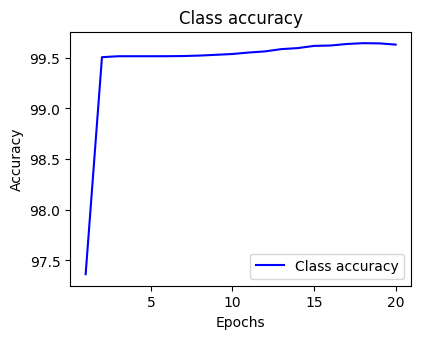

In [ ]:
set_figsize((4.4, 3.3))
plot_cls_acc(cls_acc_all)

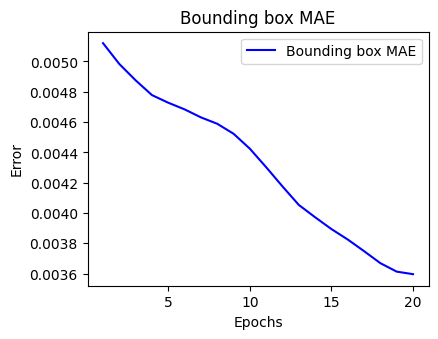

In [ ]:
plot_bbox_mae(bbox_mae_all)

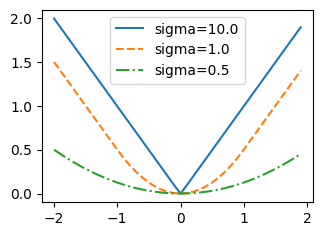

In [ ]:
def smooth_l1_loss(pred, target, scalar=1.0):
  delta = pred - target
  mask = abs(delta) < 1 / (scalar ** 2)

  #varianta 1
  #out = torch.ones_like(delta)
  #out[mask] = ((scalar * delta) ** 2)/2
  #out[~mask] = abs(delta) - 0.5 / (scalar ** 2)

# varianta 2
  out = torch.where(mask,((scalar * delta) ** 2)/2,abs(delta) - 0.5 / (scalar ** 2))
  return out



'''
def smooth_l1(data, scalar):
    out = []
    for i in data:
        if abs(i) < 1 / (scalar ** 2):
            out.append(((scalar * i) ** 2) / 2)
        else:
            out.append(abs(i) - 0.5 / (scalar ** 2))
    return torch.tensor(out)

'''

sigmas = [10, 1, 0.5]
lines = ['-', '--', '-.']
x = torch.arange(-2, 2, 0.1)
set_figsize()

for l, s in zip(lines, sigmas):
    y = smooth_l1_loss(x, target=0, scalar=s)
    plt.plot(x, y, l, label='sigma=%.1f' % s)
plt.legend();

Exercitiul 2

2. In the experiment we used cross-entropy loss for class prediction:
denoting by $p_j$ the predicted probability for the ground-truth class $j$, the cross-entropy loss is $-\log p_j$. Replace the cross-entropy loss with the *focal loss*: given hyperparameter $\gamma > 0$, this loss is defined as:
  $$ - (1-p_j)^{\gamma} \log p_j.$$

  As we can see, increasing $\gamma$
  can effectively reduce the relative loss
  for well-classified examples (e.g., $p_j > 0.5$)
  so the training
  can focus more on those difficult examples that are misclassified.

Acum schimbi asta cu:

$$
FL = - (1 - p_t)^\gamma \log(p_t)
$$

unde $p_t$ e probabilitatea prezisă pentru **clasa adevărată**
(softmax pe logits).

In [ ]:
def focal_loss(logits, targets, gamma=2.0, reduction='none'):
    """
    logits: (N, C)  - scoruri ne-normalizate
    targets: (N,)   - etichete corecte
    """
    log_probs = torch.nn.functional.log_softmax(logits, dim=1)  # (N, C)
    probs = log_probs.exp()                                     # (N, C)

    idx = torch.arange(targets.shape[0], device=targets.device)
    p_t = probs[idx, targets]                                   # (N,)
    log_p_t = log_probs[idx, targets]                           # (N,)

    loss = -((1 - p_t) ** gamma) * log_p_t                      # (N,)

    if reduction == 'mean':
        return loss.mean()
    if reduction == 'sum':
        return loss.sum()
    return loss


In [ ]:
'''
cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = nn.L1Loss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = cls_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    bbox = bbox_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks).mean(dim=1)
    return cls + bbox

BEFORE
'''

cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = nn.L1Loss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = focal_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1),2.0,reduction='none').reshape(batch_size, -1).mean(dim=1)
    bbox = smooth_l1_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks,1.0).mean(dim=1)
    return cls + bbox

In [ ]:
def cls_eval(cls_preds, cls_labels):
    # Because the class prediction results are on the final dimension,
    # `argmax` needs to specify this dimension
    return float((cls_preds.argmax(dim=-1).type(
        cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

In [ ]:
def train(net, train_iter, num_epochs, device):
  cls_acc_all = []
  bbox_mae_all = []
  net = net.to(device)
  for epoch in range(num_epochs):
    # Sum of training accuracy, no. of examples in sum of training accuracy,
    # Sum of absolute error, no. of examples in sum of absolute error
    total_cls = 0
    total_cls_labels = 0
    total_bbox = 0
    total_bbox_labels = 0
    net.train()
    for features, target in train_iter:
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # Generate multiscale anchor boxes and predict their classes and
        # offsets
        anchors, cls_preds, bbox_preds = net(X)
        # Label the classes and offsets of these anchor boxes
        bbox_labels, bbox_masks, cls_labels = multibox_target(anchors, Y)
        # Calculate the loss function using the predicted and labeled values
        # of the classes and offsets
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels,
                      bbox_masks)
        l.mean().backward()
        trainer.step()
        total_cls += cls_eval(cls_preds, cls_labels)
        total_cls_labels += cls_labels.numel()
        total_bbox += bbox_eval(bbox_preds, bbox_labels, bbox_masks)
        total_bbox_labels += bbox_labels.numel()
    cls_acc, bbox_mae = total_cls / total_cls_labels * 100, total_bbox / total_bbox_labels
    cls_acc_all.append(cls_acc)
    bbox_mae_all.append(bbox_mae)
    print(f'Epoch {epoch + 1}, Class accuracy {cls_acc:.2f}, Bounding box MAE {bbox_mae:.2e}')

  return cls_acc_all, bbox_mae_all

In [ ]:
def plot_cls_acc(cls_acc_all):
    epochs = range(1, len(cls_acc_all) + 1)
    plt.plot(epochs, cls_acc_all, 'b', label='Class accuracy')
    plt.title('Class accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
def plot_bbox_mae(bbox_mae_all):
    epochs = range(1, len(bbox_mae_all) + 1)
    plt.plot(epochs, bbox_mae_all, 'b', label='Bounding box MAE')
    plt.title('Bounding box MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

In [ ]:
num_epochs = 20
cls_acc_all, bbox_mae_all = train(net, train_iter, num_epochs, device) #2 min

Epoch 1, Class accuracy 99.66, Bounding box MAE 1.79e-03
Epoch 2, Class accuracy 99.67, Bounding box MAE 1.65e-03
Epoch 3, Class accuracy 99.67, Bounding box MAE 1.64e-03
Epoch 4, Class accuracy 99.67, Bounding box MAE 1.68e-03
Epoch 5, Class accuracy 99.67, Bounding box MAE 1.66e-03
Epoch 6, Class accuracy 99.67, Bounding box MAE 1.54e-03
Epoch 7, Class accuracy 99.67, Bounding box MAE 1.61e-03
Epoch 8, Class accuracy 99.68, Bounding box MAE 1.52e-03
Epoch 9, Class accuracy 99.68, Bounding box MAE 1.50e-03
Epoch 10, Class accuracy 99.69, Bounding box MAE 1.51e-03
Epoch 11, Class accuracy 99.69, Bounding box MAE 1.44e-03
Epoch 12, Class accuracy 99.69, Bounding box MAE 1.42e-03
Epoch 13, Class accuracy 99.70, Bounding box MAE 1.38e-03
Epoch 14, Class accuracy 99.69, Bounding box MAE 1.42e-03
Epoch 15, Class accuracy 99.70, Bounding box MAE 1.38e-03
Epoch 16, Class accuracy 99.70, Bounding box MAE 1.34e-03
Epoch 17, Class accuracy 99.70, Bounding box MAE 1.38e-03
Epoch 18, Class accurac

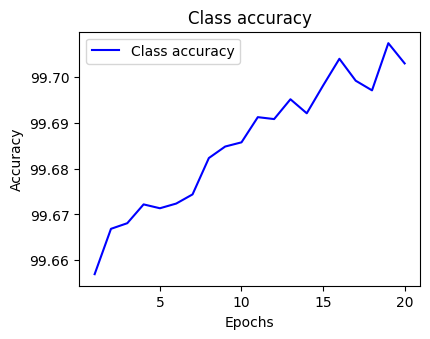

In [ ]:
set_figsize((4.4, 3.3))
plot_cls_acc(cls_acc_all)

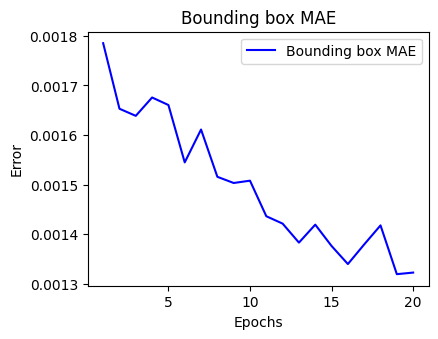

In [ ]:
plot_bbox_mae(bbox_mae_all)

Exercitiul 3

In the loss function, assign different weight hyperparameters to the class loss and the offset loss.

In [ ]:
def focal_loss(logits, targets, gamma=2.0, reduction='none'):
    """
    logits: (N, C)  - scoruri ne-normalizate
    targets: (N,)   - etichete corecte
    """
    log_probs = torch.nn.functional.log_softmax(logits, dim=1)  # (N, C)
    probs = log_probs.exp()                                     # (N, C)

    idx = torch.arange(targets.shape[0], device=targets.device)
    p_t = probs[idx, targets]                                   # (N,)
    log_p_t = log_probs[idx, targets]                           # (N,)

    loss = -((1 - p_t) ** gamma) * log_p_t                      # (N,)

    if reduction == 'mean':
        return loss.mean()
    if reduction == 'sum':
        return loss.sum()
    return loss


In [ ]:
cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = nn.L1Loss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks, alpha=1.0, beta=1.0, gamma=2.0):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = focal_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1),2.0,reduction='none').reshape(batch_size, -1).mean(dim=1)
    bbox = smooth_l1_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks,1.0).mean(dim=1)
    return (alpha * cls + beta * bbox).mean()


In [ ]:
def cls_eval(cls_preds, cls_labels):
    # Because the class prediction results are on the final dimension,
    # `argmax` needs to specify this dimension
    return float((cls_preds.argmax(dim=-1).type(
        cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

In [ ]:
def train(net, train_iter, num_epochs, device):
  cls_acc_all = []
  bbox_mae_all = []
  net = net.to(device)
  for epoch in range(num_epochs):
    # Sum of training accuracy, no. of examples in sum of training accuracy,
    # Sum of absolute error, no. of examples in sum of absolute error
    total_cls = 0
    total_cls_labels = 0
    total_bbox = 0
    total_bbox_labels = 0
    net.train()
    for features, target in train_iter:
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # Generate multiscale anchor boxes and predict their classes and
        # offsets
        anchors, cls_preds, bbox_preds = net(X)
        # Label the classes and offsets of these anchor boxes
        bbox_labels, bbox_masks, cls_labels = multibox_target(anchors, Y)
        # Calculate the loss function using the predicted and labeled values
        # of the classes and offsets
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels,
                      bbox_masks)
        l.mean().backward()
        trainer.step()
        total_cls += cls_eval(cls_preds, cls_labels)
        total_cls_labels += cls_labels.numel()
        total_bbox += bbox_eval(bbox_preds, bbox_labels, bbox_masks)
        total_bbox_labels += bbox_labels.numel()
    cls_acc, bbox_mae = total_cls / total_cls_labels * 100, total_bbox / total_bbox_labels
    cls_acc_all.append(cls_acc)
    bbox_mae_all.append(bbox_mae)
    print(f'Epoch {epoch + 1}, Class accuracy {cls_acc:.2f}, Bounding box MAE {bbox_mae:.2e}')

  return cls_acc_all, bbox_mae_all

In [ ]:
def plot_cls_acc(cls_acc_all):
    epochs = range(1, len(cls_acc_all) + 1)
    plt.plot(epochs, cls_acc_all, 'b', label='Class accuracy')
    plt.title('Class accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
def plot_bbox_mae(bbox_mae_all):
    epochs = range(1, len(bbox_mae_all) + 1)
    plt.plot(epochs, bbox_mae_all, 'b', label='Bounding box MAE')
    plt.title('Bounding box MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

In [ ]:
num_epochs = 20
cls_acc_all, bbox_mae_all = train(net, train_iter, num_epochs, device) #2 min

Epoch 1, Class accuracy 99.71, Bounding box MAE 1.31e-03
Epoch 2, Class accuracy 99.72, Bounding box MAE 1.23e-03
Epoch 3, Class accuracy 99.72, Bounding box MAE 1.19e-03
Epoch 4, Class accuracy 99.73, Bounding box MAE 1.16e-03
Epoch 5, Class accuracy 99.73, Bounding box MAE 1.15e-03
Epoch 6, Class accuracy 99.73, Bounding box MAE 1.14e-03
Epoch 7, Class accuracy 99.74, Bounding box MAE 1.14e-03
Epoch 8, Class accuracy 99.74, Bounding box MAE 1.14e-03
Epoch 9, Class accuracy 99.74, Bounding box MAE 1.14e-03
Epoch 10, Class accuracy 99.75, Bounding box MAE 1.13e-03
Epoch 11, Class accuracy 99.75, Bounding box MAE 1.13e-03
Epoch 12, Class accuracy 99.75, Bounding box MAE 1.14e-03
Epoch 13, Class accuracy 99.75, Bounding box MAE 1.13e-03
Epoch 14, Class accuracy 99.75, Bounding box MAE 1.14e-03
Epoch 15, Class accuracy 99.76, Bounding box MAE 1.13e-03
Epoch 16, Class accuracy 99.76, Bounding box MAE 1.14e-03
Epoch 17, Class accuracy 99.76, Bounding box MAE 1.14e-03
Epoch 18, Class accurac

#**Laboratorul 8**

Exercitiul 1

1. We initialized the transposed convolutional layer by bilinear interpolation. Use Xavier initialization for the transposed convolutional layer and run the necessary experiment. How does the performance change?


#Varianta fara Xavier

In [ ]:
exit()

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)

net = nn.Sequential(*list(pretrained_net.children())[:-2])

num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32))

W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

In [ ]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = load_data_voc(batch_size, crop_size) #1 min

/tmp/ipython-input-1745639039.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


read 1114 examples
read 1078 examples


In [ ]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            total_hits += accuracy(net(X), y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs,
               device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(
                net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'loss {total_loss / total_samples:.3f}, train acc '
            f'{total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [ ]:
num_epochs, lr, wd, device = 5, 0.001, 1e-3, try_gpu()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(net, train_iter, test_iter, loss, trainer, num_epochs, device) #6 min

loss 1.131, train acc 74.840, test acc 81.821
loss 0.635, train acc 82.584, test acc 83.607
loss 0.515, train acc 84.793, test acc 84.508
loss 0.460, train acc 85.982, test acc 84.828
loss 0.417, train acc 86.981, test acc 85.300


#Varianta cu Xavier

In [ ]:
exit()

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)

net = nn.Sequential(*list(pretrained_net.children())[:-2])

num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,kernel_size=64, padding=16, stride=32))

#W = bilinear_kernel(num_classes, num_classes, 64)
#net.transpose_conv.weight.data.copy_(W);
nn.init.xavier_uniform_(net.transpose_conv.weight)
if net.final_conv.bias is not None:
    nn.init.zeros_(net.transpose_conv.bias)

Bilinear init: pleacă “deja ca un upsampling ok” → de obicei învață mai repede și are accuracy mai bună în primele epoci.

Xavier init: pleacă random → de obicei merge mai prost la început, poate recupera dacă antrenezi suficient, dar în 5 epoci e foarte posibil să rămână sub bilinear.

In [ ]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = load_data_voc(batch_size, crop_size) #1 min

/tmp/ipython-input-1276357601.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


read 1114 examples
read 1078 examples


In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            total_hits += accuracy(net(X), y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs,
               device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(
                net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'loss {total_loss / total_samples:.3f}, train acc '
            f'{total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [ ]:
num_epochs, lr, wd, device = 5, 0.001, 1e-3, try_gpu()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(net, train_iter, test_iter, loss, trainer, num_epochs, device) #6 min

loss 2.795, train acc 67.986, test acc 72.870
loss 2.331, train acc 72.746, test acc 72.896
loss 1.965, train acc 72.517, test acc 72.812
loss 1.704, train acc 72.617, test acc 72.797
loss 1.541, train acc 72.692, test acc 72.799


Exercitiul 2

2. The original fully convolutional network paper also uses outputs of some intermediate CNN layers to construct the semantic segmentation, like in the figure below. We only implemented FCN-32s using the outputs of the last stage in ResNet-18 (corresponding to `pool5` in the figure below). Implement FCN-16s by using the outputs of the penultimate stage in the ResNet-18 network (corresponding to `pool4` in the figure below).

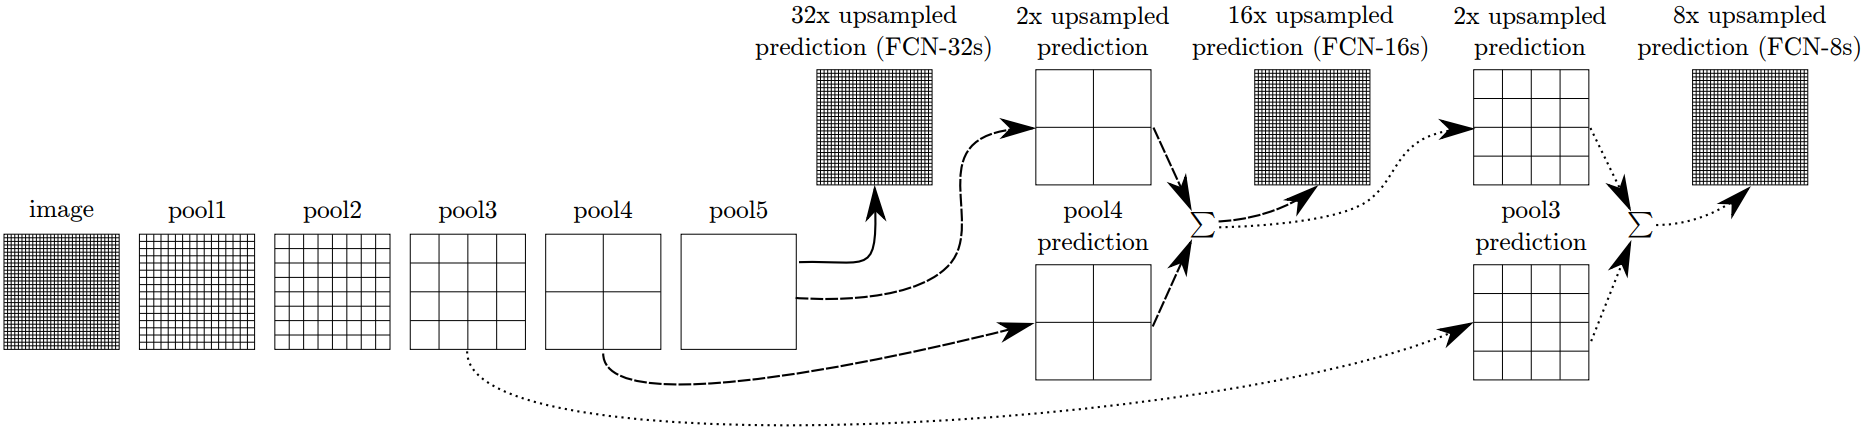

In [ ]:
exit()

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)

'''
net = nn.Sequential(*list(pretrained_net.children())[:-2])

num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32))

W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);
'''

class FCN16s(nn.Module):
  def __init__(self, num_classes=21):
    super(FCN16s,self).__init__()
    resnet = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)

    self.layer3 = nn.Sequential(*list(resnet.children())[:-3])
    self.layer4 = list(resnet.children())[-3]

    self.proj_5 = nn.Conv2d(512,num_classes,kernel_size=1)
    self.proj_4 = nn.Conv2d(256,num_classes,kernel_size=1)

    self.upsample_x2 = nn.ConvTranspose2d(num_classes,num_classes,kernel_size=4,stride=2,padding=1)
    self.upsample_x16 = nn.ConvTranspose2d(num_classes,num_classes,kernel_size=32,stride=16,padding=8)

    self.init_weight(num_classes)

  def init_weight(self,num_classes):
    W1 = bilinear_kernel(num_classes,num_classes,4)
    W2 = bilinear_kernel(num_classes,num_classes,32)

    self.upsample_x2.weight.data.copy_(W1)
    self.upsample_x16.weight.data.copy_(W2)

  def forward(self,x):
    firstX = self.layer3(x)

    secondX = self.layer4(firstX)
    secondX = self.proj_5(secondX)
    secondX = self.upsample_x2(secondX)

    firstX = self.proj_4(firstX)
    firstX = firstX + secondX

    x = self.upsample_x16(firstX)

    return x

net = FCN16s()

In [ ]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = load_data_voc(batch_size, crop_size) #1 min

/tmp/ipython-input-3886519764.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


read 1114 examples
read 1078 examples


In [ ]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            total_hits += accuracy(net(X), y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs,
               device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(
                net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'loss {total_loss / total_samples:.3f}, train acc '
            f'{total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [ ]:
num_epochs, lr, wd, device = 5, 0.001, 1e-3, try_gpu()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(net, train_iter, test_iter, loss, trainer, num_epochs, device) #6 min

loss 1.151, train acc 74.353, test acc 81.328
loss 0.620, train acc 82.767, test acc 83.543
loss 0.514, train acc 84.714, test acc 84.395
loss 0.458, train acc 85.922, test acc 84.964
loss 0.413, train acc 87.046, test acc 85.139


#**Labnoratorul 9**

Exercitiul 1

1. Use a GRU with $2$ recurrent layers for the decoder part. Train the model for $1$ epoch and evaluate it on an instance from the test set

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import spacy
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

In [ ]:
def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url, cache_dir=".")
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    fp = zipfile.ZipFile(fname, 'r')
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flickr8k_Dataset')
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text')

'./Flickr8k_text'

In [ ]:
spacy_en = spacy.load('en_core_web_sm')

In [ ]:
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<BOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<BOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1

                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

In [ ]:
def load_captions(path):
    captions_list = []
    image_captions = {}
    with open(path, "r") as file:
        for line in file.readlines():
            words = line.strip("\n").split()
            caption = ' '.join(words[1:])
            captions_list.append(caption)

    return captions_list

In [ ]:
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(load_captions("Flickr8k.token.txt"))

In [ ]:
def split_data(all_captions_path, img_list_path, name):
    img_names = []
    with open(img_list_path, "r") as file:
        for line in file.readlines():
            img_name = line.strip("\n").split(".")[0]
            img_names.append(img_name)

    lines = []
    with open(all_captions_path, "r") as file:
        for line in file.readlines():
            words = line.replace(";",",").strip("\n").split()
            img_name = words[0].split(".")[0]

            if img_name in img_names:
                new_line = img_name + ".jpg;" + " ".join(words[1:])
                lines.append(new_line)

    with open(name, "w") as file:
        file.writelines("image;caption\n")
        lines = map(lambda x:x + '\n', lines)
        file.writelines(lines)

In [ ]:
split_data("Flickr8k.token.txt", "Flickr_8k.trainImages.txt", "train.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.devImages.txt", "validation.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.testImages.txt", "test.txt")

In [ ]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, vocab, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep=";")
        self.vocab = vocab
        self.transform = transform

        # Get img, caption columns
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<BOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)

In [ ]:
class CollateDataset:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)

        return imgs, targets

In [ ]:
def get_loader(
    root_folder,
    annotation_file,
    vocab,
    transform,
    batch_size=32,
    num_workers=2,
    shuffle=True,
    pin_memory=True,
):
    dataset = FlickrDataset(root_folder, annotation_file, vocab, transform=transform)

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=CollateDataset(pad_idx=dataset.vocab.stoi["<PAD>"]),
    )

    return loader, dataset

In [ ]:
transform = transforms.Compose(
        [transforms.Resize((299, 299)),
         transforms.ToTensor(),
         transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
         ]
    )

train_loader, train_dataset = get_loader(
    "Flicker8k_Dataset", "train.txt", vocab, transform=transform
)

val_loader, val_dataset = get_loader(
    "Flicker8k_Dataset", "validation.txt", vocab, transform=transform
)

test_loader, test_dataset = get_loader(
    "Flicker8k_Dataset", "test.txt", vocab, transform=transform, shuffle=False
)

In [ ]:
for idx, (imgs, captions) in enumerate(train_loader):
        print(imgs.shape)
        print(captions.shape)
        break

torch.Size([32, 3, 299, 299])
torch.Size([24, 32])


In [ ]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.inception(images)[0]
        return self.dropout(self.relu(features))

In [ ]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.GRU(embed_size, hidden_size, num_layers)#aici--------------------------------------------------------
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        _, states = self.lstm(features.unsqueeze(0))
        hiddens, _ = self.lstm(embeddings, states)
        outputs = self.linear(hiddens)
        return outputs

In [ ]:
class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=40):
        result_caption = []

        with torch.no_grad():
            x = self.encoderCNN(image).unsqueeze(0)
            states = None

            for _ in range(max_length):
                hiddens, states = self.decoderRNN.lstm(x, states)#aici practic acceseaza lstm din DecoderRNN care ii doar o variabila
                output = self.decoderRNN.linear(hiddens.squeeze(0))
                predicted = output.argmax(0)
                result_caption.append(predicted.item())
                x = self.decoderRNN.embed(predicted).unsqueeze(0)

                if vocabulary.itos[predicted.item()] == "<EOS>":
                    break

        return [vocabulary.itos[idx] for idx in result_caption]

In [ ]:
embed_size = 256
hidden_size = 256
vocab_size = len(vocab)
num_layers = 2 #aici--------------------------------------------------------------------------------------
learning_rate = 3e-4
num_epochs = 1
device = try_gpu()
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
loss_criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])

In [ ]:
for name, param in model.encoderCNN.inception.named_parameters():
        if "fc.weight" in name or "fc.bias" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

In [ ]:
train_loss = [] #5 min
dev_loss = []

for epoch in range(num_epochs):
    model.train()

    train_run_loss = []
    dev_run_loss = []
    index = 0

    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        outputs = model(imgs, captions)
        loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
        loss.backward()
        optimizer.step()
        train_run_loss.append(loss.item())
        if (index+1) % 100 == 0:
            print("[Train {}] Iteration {} | Running Loss: {}".format(epoch+1, index+1, round(np.mean(train_run_loss), 4)))
        index += 1

    avg_loss = np.mean(train_run_loss)
    train_loss.append(avg_loss)
    print("[Train] Epoch {} | Average Loss: {}".format(epoch+1, round(avg_loss, 4)))

    index = 0
    for idx, (imgs, captions) in enumerate(val_loader):
        with torch.no_grad():
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions)
            loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
            dev_run_loss.append(loss.item())
            index += 1

    avg_loss = np.mean(dev_run_loss)
    dev_loss.append(avg_loss)
    print("[Valid] Epoch {} | Average Loss: {}".format(epoch+1, round(avg_loss, 4)))

[Train 1] Iteration 100 | Running Loss: 7.9995
[Train 1] Iteration 200 | Running Loss: 7.9969
[Train 1] Iteration 300 | Running Loss: 7.994
[Train 1] Iteration 400 | Running Loss: 7.9912
[Train 1] Iteration 500 | Running Loss: 7.9884
[Train 1] Iteration 600 | Running Loss: 7.9859
[Train 1] Iteration 700 | Running Loss: 7.9829
[Train 1] Iteration 800 | Running Loss: 7.9802
[Train 1] Iteration 900 | Running Loss: 7.9774
[Train] Epoch 1 | Average Loss: 7.9764
[Valid] Epoch 1 | Average Loss: 7.9509


In [ ]:
def print_example(model, device, loader, dataset):
    model.eval()
    img, caption = next(iter(loader))
    caption = caption.transpose(0, 1)
    plt.imshow(img[0].permute(1, 2, 0))
    print("Example CORRECT: " + " ".join([dataset.vocab.itos[idx] for idx in caption[0].tolist()
      if dataset.vocab.itos[idx] not in {"<PAD>", "<BOS>", "<EOS>"}]))
    print(
        "Example OUTPUT: "
        + " ".join(model.caption_image(img[0].unsqueeze(0).to(device), dataset.vocab))
    )

Example CORRECT: a blond woman in a blue shirt appears to wait for a ride .
Example OUTPUT: tutu target bends participate meal meal meal hole smaller cartwheel start bread railing bread splits crystal braids braids dried smaller good observing bench bench for sprinkler top top waterskier abandoned look look igloo waterskier walkway walkway medium walkway walkway medium


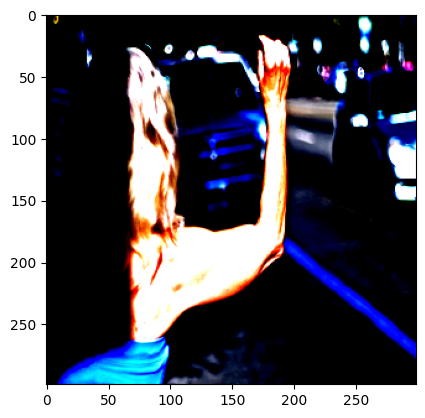

In [ ]:
print_example(model, device, test_loader, test_dataset)

Exercitiul 2

2. Replace the LSTM layer in the decoder with two attention layers. Use any type of attention as long as it fits (for example, the second attention layer must be capable of mixing the embeddings with the state, while the first one only has to deal with one type of input). Train the model for $1$ epoch and evaluate it on an instance from the test set.

In [ ]:
exit()

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
from PIL import Image
import spacy
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile


# ----------------------- UTILS -----------------------
def download(url, cache_dir=os.path.join('..', 'data')):
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    fname = download(url, cache_dir=".")
    base_dir = os.path.dirname(fname)
    ext = os.path.splitext(fname)[1]
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        raise ValueError('Only zip/tar files can be extracted.')
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else base_dir

def try_gpu(i=0):
    return torch.device(f'cuda:{i}') if torch.cuda.device_count() >= i + 1 else torch.device('cpu')


# ----------------------- DOWNLOAD DATA -----------------------
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flickr8k_Dataset')
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text')


# ----------------------- VOCABULARY -----------------------
spacy_en = spacy.load("en_core_web_sm")

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<BOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] = frequencies.get(word, 0) + 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized_text]


def load_captions(path):
    captions_list = []
    with open(path, "r") as file:
        for line in file.readlines():
            words = line.strip("\n").split()
            captions_list.append(' '.join(words[1:]))
    return captions_list


vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(load_captions("Flickr8k.token.txt"))


# ----------------------- SPLIT DATA -----------------------
def split_data(all_captions_path, img_list_path, name):
    img_names = []
    with open(img_list_path, "r") as file:
        for line in file.readlines():
            img_names.append(line.strip("\n").split(".")[0])

    lines = []
    with open(all_captions_path, "r") as file:
        for line in file.readlines():
            words = line.replace(";",",").strip("\n").split()
            img_name = words[0].split(".")[0]
            if img_name in img_names:
                new_line = img_name + ".jpg;" + " ".join(words[1:])
                lines.append(new_line)

    with open(name, "w") as file:
        file.writelines("image;caption\n")
        lines = map(lambda x: x + '\n', lines)
        file.writelines(lines)

split_data("Flickr8k.token.txt", "Flickr_8k.trainImages.txt", "train.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.devImages.txt", "validation.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.testImages.txt", "test.txt")


# ----------------------- DATASET -----------------------
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, vocab, transform=None):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep=";")
        self.vocab = vocab
        self.transform = transform
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<BOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])
        return img, torch.tensor(numericalized_caption)

class CollateDataset:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)
        return imgs, targets

def get_loader(root_folder, annotation_file, vocab, transform, batch_size=32, shuffle=True):
    dataset = FlickrDataset(root_folder, annotation_file, vocab, transform=transform)
    loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=shuffle,
                        collate_fn=CollateDataset(pad_idx=dataset.vocab.stoi["<PAD>"]))
    return loader, dataset


transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
])

train_loader, train_dataset = get_loader("Flicker8k_Dataset", "train.txt", vocab, transform)
val_loader, val_dataset     = get_loader("Flicker8k_Dataset", "validation.txt", vocab, transform)
test_loader, test_dataset   = get_loader("Flicker8k_Dataset", "test.txt", vocab, transform, shuffle=False)


# ----------------------- ATTENTION UTILS -----------------------
def sequence_mask(X, valid_len, value=0):
    maxlen = X.size(1)
    mask = torch.arange(maxlen, device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

def masked_softmax(X, valid_lens):
    if valid_lens is None:
        return F.softmax(X, dim=-1)
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return F.softmax(X.reshape(shape), dim=-1)

class AdditiveAttention(nn.Module):
    def __init__(self, key_size, query_size, num_hiddens, dropout):
        super().__init__()
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        queries, keys = self.W_q(queries), self.W_k(keys)
        features = torch.tanh(queries.unsqueeze(2) + keys.unsqueeze(1))
        scores = self.w_v(features).squeeze(-1)
        attn = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(attn), values)


# ----------------------- MODEL -----------------------
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.inception = models.inception_v3(
            weights=models.Inception_V3_Weights.IMAGENET1K_V1,
            aux_logits=True
        )
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        out = self.inception(images)

        # când aux_logits=True în train -> out = InceptionOutputs(logits, aux_logits)
        if hasattr(out, "logits"):
            out = out.logits

        return self.dropout(self.relu(out))


class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(0.5)
        self.attn1 = AdditiveAttention(embed_size, embed_size, hidden_size, dropout=0.0)
        self.attn2 = AdditiveAttention(embed_size, embed_size, hidden_size, dropout=0.0)
        self.linear = nn.Linear(embed_size, vocab_size)

    def forward(self, features, captions):
        emb = self.dropout(self.embed(captions)).permute(1, 0, 2)
        text_ctx = self.attn1(emb, emb, emb, None)
        img_mem = features.unsqueeze(1)
        fused = self.attn2(text_ctx, img_mem, img_mem, None)
        out = self.linear(fused).permute(1, 0, 2)
        return out

class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super().__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions_in):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions_in)
        return outputs

    def caption_image(self, image, vocabulary, max_length=40):
        self.eval()
        with torch.no_grad():
            feat = self.encoderCNN(image)
            tokens = [vocabulary.stoi["<BOS>"]]
            for _ in range(max_length):
                inp = torch.tensor(tokens, device=feat.device).unsqueeze(1)
                logits = self.decoderRNN(feat, inp)
                next_id = int(logits[-1, 0].argmax(dim=-1).item())
                tokens.append(next_id)
                if vocabulary.itos[next_id] == "<EOS>":
                    break
        words = []
        for t in tokens[1:]:
            w = vocabulary.itos[t]
            if w in ("<EOS>", "<PAD>"):
                break
            words.append(w)
        return words


# ----------------------- TRAINING -----------------------
device = try_gpu()
embed_size = 256
hidden_size = 256
vocab_size = len(vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 1

model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])

for name, param in model.encoderCNN.inception.named_parameters():
    param.requires_grad = ("fc.weight" in name) or ("fc.bias" in name)

model.train()
for epoch in range(num_epochs):
    running_loss = []
    for imgs, captions in train_loader:
        imgs, captions = imgs.to(device), captions.to(device)
        captions_in = captions[:-1, :]
        targets = captions[1:, :]
        outputs = model(imgs, captions_in)
        loss = criterion(outputs.reshape(-1, outputs.shape[2]), targets.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss.append(loss.item())
    print(f"[Epoch {epoch+1}] Train Loss: {np.mean(running_loss):.4f}")


# ----------------------- EVALUATION -----------------------
def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img.cpu() * std + mean

def print_example(model, device, loader, dataset):
    model.eval()
    imgs, captions = next(iter(loader))
    img0 = imgs[0:1].to(device)
    cap0 = captions[:, 0].tolist()
    gt = " ".join([dataset.vocab.itos[i] for i in cap0 if dataset.vocab.itos[i] not in {"<PAD>", "<BOS>", "<EOS>"}])
    pred = " ".join(model.caption_image(img0, dataset.vocab))
    plt.imshow(unnormalize(imgs[0]).permute(1,2,0).clamp(0,1))
    plt.axis("off")
    print("Example CORRECT:", gt)
    print("Example OUTPUT :", pred)

print_example(model, device, test_loader, test_dataset)

#Laboratorul 10

Exercitiul 1

1. What will happen if we use the standard ReLU activation rather than LeakyReLU?

Cu LeakyReLU

In [ ]:
import torch
import torchvision
from torch import nn
from matplotlib import pyplot as plt
from IPython import display
import warnings
import os
import requests
import zipfile
import tarfile

In [ ]:
X = torch.normal(0.0, 1, (1000, 2))
A = torch.tensor([[1, 2], [-0.1, 0.5]])
b = torch.tensor([1, 2])
data = torch.matmul(X, A) + b

In [ ]:
def set_figsize(figsize=(3.5, 2.5)):
    """Set the figure size for matplotlib."""
    plt.rcParams['figure.figsize'] = figsize

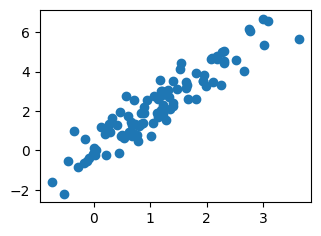

In [ ]:
set_figsize()
plt.scatter(data[:100, (0)].detach().numpy(), data[:100, (1)].detach().numpy());

In [ ]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [ ]:
batch_size = 8
data_iter = load_array((data,), batch_size)

In [ ]:
net_G = nn.Sequential(nn.Linear(2, 2))

In [ ]:
net_D = nn.Sequential(
    nn.Linear(2, 5), nn.Tanh(),
    nn.Linear(5, 3), nn.Tanh(),
    nn.Linear(3, 1))

In [ ]:
def update_D(X, Z, net_D, net_G, loss, trainer_D):
    """Update discriminator."""
    batch_size = X.shape[0]
    ones = torch.ones((batch_size,), device=X.device)
    zeros = torch.zeros((batch_size,), device=X.device)
    trainer_D.zero_grad()
    real_Y = net_D(X)
    fake_X = net_G(Z)
    # Do not need to compute gradient for `net_G`, detach it from
    # computing gradients.
    fake_Y = net_D(fake_X.detach())
    loss_D = (loss(real_Y, ones.reshape(real_Y.shape)) +
              loss(fake_Y, zeros.reshape(fake_Y.shape))) / 2
    loss_D.backward()
    trainer_D.step()
    return loss_D

In [ ]:
def update_G(Z, net_D, net_G, loss, trainer_G):
    """Update generator."""
    batch_size = Z.shape[0]
    ones = torch.ones((batch_size,), device=Z.device)
    trainer_G.zero_grad()
    # We could reuse `fake_X` from `update_D` to save computation
    fake_X = net_G(Z)
    # Recomputing `fake_Y` is needed since `net_D` is changed
    fake_Y = net_D(fake_X)
    loss_G = loss(fake_Y, ones.reshape(fake_Y.shape))
    loss_G.backward()
    trainer_G.step()
    return loss_G

In [ ]:
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim),     axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

class Animator:
    """For plotting data in animation."""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        """Defined in :numref:`sec_utils`"""
        # Incrementally plot multiple lines
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Use a lambda function to capture arguments
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # Add multiple data points into the figure
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [ ]:
def train(net_D, net_G, data_iter, num_epochs, lr_D, lr_G, latent_dim, data):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)
    trainer_D = torch.optim.Adam(net_D.parameters(), lr=lr_D)
    trainer_G = torch.optim.Adam(net_G.parameters(), lr=lr_G)
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.3)
    D_loss = 0
    G_loss = 0
    total_examples = 0
    for epoch in range(num_epochs):
        # Train one epoch
        for (X,) in data_iter:
            batch_size = X.shape[0]
            Z = torch.normal(0, 1, size=(batch_size, latent_dim))
            D_loss += update_D(X, Z, net_D, net_G, loss, trainer_D)
            G_loss += update_G(Z, net_D, net_G, loss, trainer_G)
            total_examples += batch_size
        # Visualize generated examples
        Z = torch.normal(0, 1, size=(100, latent_dim))
        fake_X = net_G(Z).detach().numpy()
        animator.axes[1].cla()
        animator.axes[1].scatter(data[:, 0], data[:, 1])
        animator.axes[1].scatter(fake_X[:, 0], fake_X[:, 1])
        animator.axes[1].legend(['real', 'generated'])
        # Show the losses
        loss_D, loss_G = D_loss/total_examples, G_loss/total_examples
        animator.add(epoch + 1, (loss_D.cpu().detach().numpy(), loss_G.cpu().detach().numpy()))
    print(f'loss_D {loss_D:.3f}, loss_G {loss_G:.3f}, ')

loss_D 0.653, loss_G 0.802, 


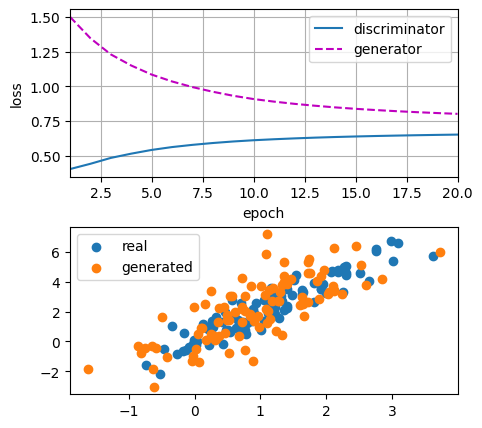

In [ ]:
lr_D, lr_G, latent_dim, num_epochs = 0.05, 0.005, 2, 20
train(net_D, net_G, data_iter, num_epochs, lr_D, lr_G,
      latent_dim, data[:100].detach().numpy())

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/pokemon.zip', 'pokemon')
pokemon = torchvision.datasets.ImageFolder(data_dir)

In [ ]:
batch_size = 256
transformer = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)
])
pokemon.transform = transformer
data_iter = torch.utils.data.DataLoader(
    pokemon, batch_size=batch_size,
    shuffle=True, num_workers=2)

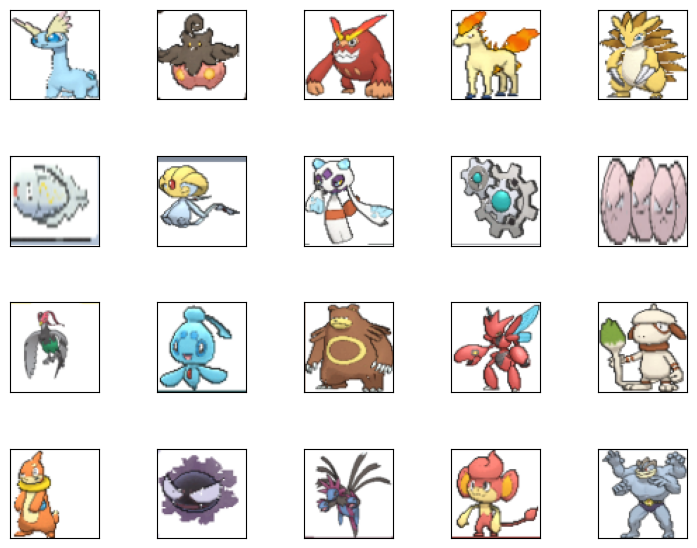

In [ ]:
warnings.filterwarnings('ignore')
set_figsize((4, 4))
for X, y in data_iter:
    imgs = X[:20,:,:,:].permute(0, 2, 3, 1)/2+0.5
    show_images(imgs, num_rows=4, num_cols=5)
    break

In [ ]:
class G_block(nn.Module):
    def __init__(self, out_channels, in_channels=3, kernel_size=4, strides=2,
                 padding=1, **kwargs):
        super(G_block, self).__init__(**kwargs)
        self.conv2d_trans = nn.ConvTranspose2d(in_channels, out_channels,
                                kernel_size, strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU()

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d_trans(X)))

In [ ]:
x = torch.zeros((2, 3, 16, 16))
g_blk = G_block(20)
g_blk(x).shape

torch.Size([2, 20, 32, 32])

In [ ]:
x = torch.zeros((2, 3, 1, 1))
g_blk = G_block(20, strides=1, padding=0)
g_blk(x).shape

torch.Size([2, 20, 4, 4])

In [ ]:
n_G = 64
net_G = nn.Sequential(
    G_block(in_channels=100, out_channels=n_G*8,
            strides=1, padding=0),                  # Output: (64 * 8, 4, 4)
    G_block(in_channels=n_G*8, out_channels=n_G*4), # Output: (64 * 4, 8, 8)
    G_block(in_channels=n_G*4, out_channels=n_G*2), # Output: (64 * 2, 16, 16)
    G_block(in_channels=n_G*2, out_channels=n_G),   # Output: (64, 32, 32)
    nn.ConvTranspose2d(in_channels=n_G, out_channels=3,
                       kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh())  # Output: (3, 64, 64)

In [ ]:
x = torch.zeros((1, 100, 1, 1))
net_G(x).shape

torch.Size([1, 3, 64, 64])

In [ ]:
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

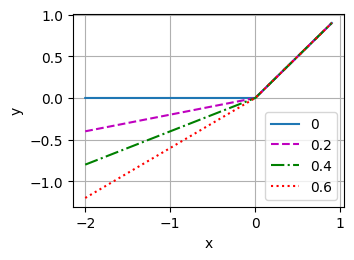

In [ ]:
alphas = [0, .2, .4, .6, .8, 1]
x = torch.arange(-2, 1, 0.1)
Y = [nn.LeakyReLU(alpha)(x).detach().numpy() for alpha in alphas]
plot(x.detach().numpy(), Y, 'x', 'y', alphas)

In [ ]:
class D_block(nn.Module):
    def __init__(self, out_channels, in_channels=3, kernel_size=4, strides=2,
                padding=1, alpha=0.2, **kwargs):
        super(D_block, self).__init__(**kwargs)
        self.conv2d = nn.Conv2d(in_channels, out_channels, kernel_size,
                                strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(alpha, inplace=True)

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d(X)))

In [ ]:
x = torch.zeros((2, 3, 16, 16))
d_blk = D_block(20)
d_blk(x).shape

torch.Size([2, 20, 8, 8])

In [ ]:
n_D = 64
net_D = nn.Sequential(
    D_block(n_D),  # Output: (64, 32, 32)
    D_block(in_channels=n_D, out_channels=n_D*2),  # Output: (64 * 2, 16, 16)
    D_block(in_channels=n_D*2, out_channels=n_D*4),  # Output: (64 * 4, 8, 8)
    D_block(in_channels=n_D*4, out_channels=n_D*8),  # Output: (64 * 8, 4, 4)
    nn.Conv2d(in_channels=n_D*8, out_channels=1,
              kernel_size=4, bias=False))  # Output: (1, 1, 1)

In [ ]:
x = torch.zeros((1, 3, 64, 64))
net_D(x).shape

torch.Size([1, 1, 1, 1])

In [ ]:
def train(net_D, net_G, data_iter, num_epochs, lr, latent_dim,
          device=try_gpu()):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)
    net_D, net_G = net_D.to(device), net_G.to(device)
    trainer_hp = {'lr': lr, 'betas': [0.5,0.999]}
    trainer_D = torch.optim.Adam(net_D.parameters(), **trainer_hp)
    trainer_G = torch.optim.Adam(net_G.parameters(), **trainer_hp)
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.3)
    D_loss = 0
    G_loss = 0
    total_examples = 0
    for epoch in range(1, num_epochs + 1):
        # Train one epoch
        for X, _ in data_iter:
            batch_size = X.shape[0]
            Z = torch.normal(0, 1, size=(batch_size, latent_dim, 1, 1))
            X, Z = X.to(device), Z.to(device)
            D_loss += update_D(X, Z, net_D, net_G, loss, trainer_D)
            G_loss += update_G(Z, net_D, net_G, loss, trainer_G)
            total_examples += batch_size
        # Show generated examples
        Z = torch.normal(0, 1, size=(21, latent_dim, 1, 1), device=device)
        # Normalize the synthetic data to N(0, 1)
        fake_x = net_G(Z).permute(0, 2, 3, 1) / 2 + 0.5
        imgs = torch.cat(
            [torch.cat([
                fake_x[i * 7 + j].cpu().detach() for j in range(7)], dim=1)
             for i in range(len(fake_x)//7)], dim=0)
        animator.axes[1].cla()
        animator.axes[1].imshow(imgs)
        # Show the losses
        loss_D, loss_G = D_loss / total_examples, G_loss / total_examples
        animator.add(epoch, (loss_D.cpu().detach().numpy(), loss_G.cpu().detach().numpy()))
    print(f'loss_D {loss_D:.3f}, loss_G {loss_G:.3f}, ')

loss_D 0.612, loss_G 1.573, 


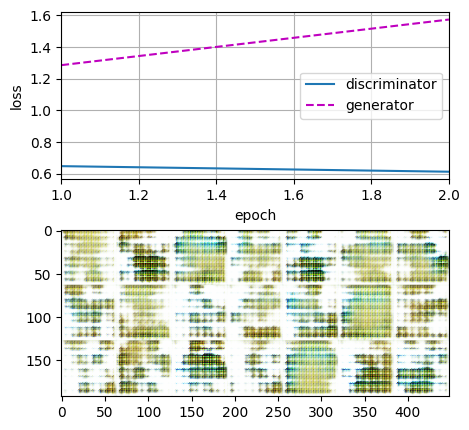

In [ ]:
latent_dim, lr, num_epochs = 100, 0.005, 2 #3 min
train(net_D, net_G, data_iter, num_epochs, lr, latent_dim)

#Cu ReLU

In [ ]:
import torch
import torchvision
from torch import nn
from matplotlib import pyplot as plt
from IPython import display
import warnings
import os
import requests
import zipfile
import tarfile

In [ ]:
X = torch.normal(0.0, 1, (1000, 2))
A = torch.tensor([[1, 2], [-0.1, 0.5]])
b = torch.tensor([1, 2])
data = torch.matmul(X, A) + b

In [ ]:
def set_figsize(figsize=(3.5, 2.5)):
    """Set the figure size for matplotlib."""
    plt.rcParams['figure.figsize'] = figsize

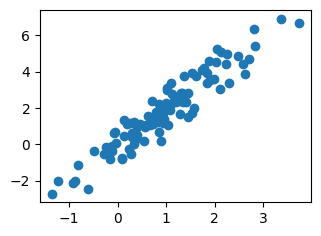

In [ ]:
set_figsize()
plt.scatter(data[:100, (0)].detach().numpy(), data[:100, (1)].detach().numpy());

In [ ]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [ ]:
batch_size = 8
data_iter = load_array((data,), batch_size)

In [ ]:
net_G = nn.Sequential(nn.Linear(2, 2))

In [ ]:
net_D = nn.Sequential(
    nn.Linear(2, 5), nn.Tanh(),
    nn.Linear(5, 3), nn.Tanh(),
    nn.Linear(3, 1))

In [ ]:
def update_D(X, Z, net_D, net_G, loss, trainer_D):
    """Update discriminator."""
    batch_size = X.shape[0]
    ones = torch.ones((batch_size,), device=X.device)
    zeros = torch.zeros((batch_size,), device=X.device)
    trainer_D.zero_grad()
    real_Y = net_D(X)
    fake_X = net_G(Z)
    # Do not need to compute gradient for `net_G`, detach it from
    # computing gradients.
    fake_Y = net_D(fake_X.detach())
    loss_D = (loss(real_Y, ones.reshape(real_Y.shape)) +
              loss(fake_Y, zeros.reshape(fake_Y.shape))) / 2
    loss_D.backward()
    trainer_D.step()
    return loss_D

In [ ]:
def update_G(Z, net_D, net_G, loss, trainer_G):
    """Update generator."""
    batch_size = Z.shape[0]
    ones = torch.ones((batch_size,), device=Z.device)
    trainer_G.zero_grad()
    # We could reuse `fake_X` from `update_D` to save computation
    fake_X = net_G(Z)
    # Recomputing `fake_Y` is needed since `net_D` is changed
    fake_Y = net_D(fake_X)
    loss_G = loss(fake_Y, ones.reshape(fake_Y.shape))
    loss_G.backward()
    trainer_G.step()
    return loss_G

In [ ]:
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim),     axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

class Animator:
    """For plotting data in animation."""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        """Defined in :numref:`sec_utils`"""
        # Incrementally plot multiple lines
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Use a lambda function to capture arguments
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # Add multiple data points into the figure
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [ ]:
def train(net_D, net_G, data_iter, num_epochs, lr_D, lr_G, latent_dim, data):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)
    trainer_D = torch.optim.Adam(net_D.parameters(), lr=lr_D)
    trainer_G = torch.optim.Adam(net_G.parameters(), lr=lr_G)
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.3)
    D_loss = 0
    G_loss = 0
    total_examples = 0
    for epoch in range(num_epochs):
        # Train one epoch
        for (X,) in data_iter:
            batch_size = X.shape[0]
            Z = torch.normal(0, 1, size=(batch_size, latent_dim))
            D_loss += update_D(X, Z, net_D, net_G, loss, trainer_D)
            G_loss += update_G(Z, net_D, net_G, loss, trainer_G)
            total_examples += batch_size
        # Visualize generated examples
        Z = torch.normal(0, 1, size=(100, latent_dim))
        fake_X = net_G(Z).detach().numpy()
        animator.axes[1].cla()
        animator.axes[1].scatter(data[:, 0], data[:, 1])
        animator.axes[1].scatter(fake_X[:, 0], fake_X[:, 1])
        animator.axes[1].legend(['real', 'generated'])
        # Show the losses
        loss_D, loss_G = D_loss/total_examples, G_loss/total_examples
        animator.add(epoch + 1, (loss_D.cpu().detach().numpy(), loss_G.cpu().detach().numpy()))
    print(f'loss_D {loss_D:.3f}, loss_G {loss_G:.3f}, ')

loss_D 0.649, loss_G 0.808, 


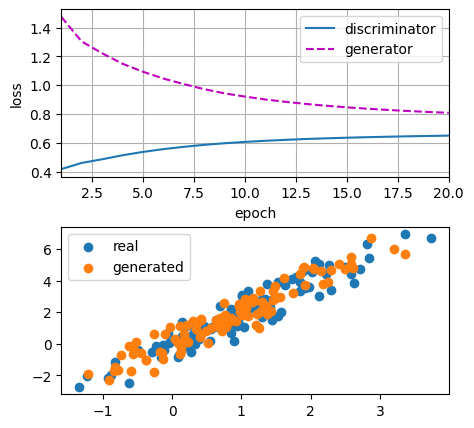

In [ ]:
lr_D, lr_G, latent_dim, num_epochs = 0.05, 0.005, 2, 20
train(net_D, net_G, data_iter, num_epochs, lr_D, lr_G,
      latent_dim, data[:100].detach().numpy())

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/pokemon.zip', 'pokemon')
pokemon = torchvision.datasets.ImageFolder(data_dir)

In [ ]:
batch_size = 256
transformer = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)
])
pokemon.transform = transformer
data_iter = torch.utils.data.DataLoader(
    pokemon, batch_size=batch_size,
    shuffle=True, num_workers=2)

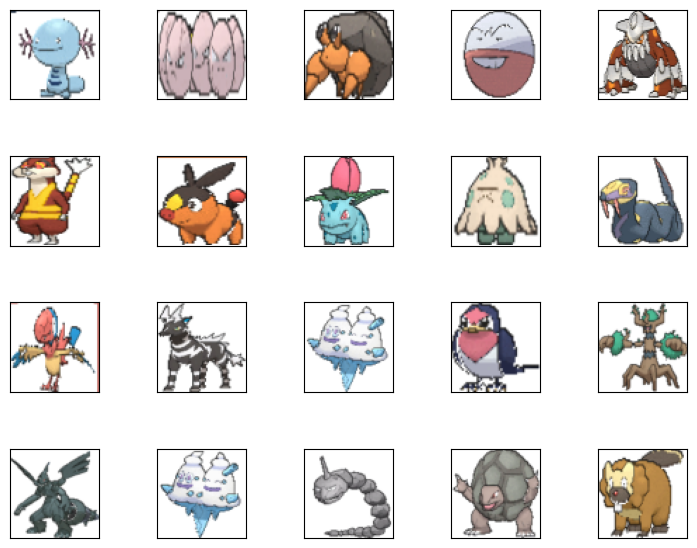

In [ ]:
warnings.filterwarnings('ignore')
set_figsize((4, 4))
for X, y in data_iter:
    imgs = X[:20,:,:,:].permute(0, 2, 3, 1)/2+0.5
    show_images(imgs, num_rows=4, num_cols=5)
    break

In [ ]:
class G_block(nn.Module):
    def __init__(self, out_channels, in_channels=3, kernel_size=4, strides=2,
                 padding=1, **kwargs):
        super(G_block, self).__init__(**kwargs)
        self.conv2d_trans = nn.ConvTranspose2d(in_channels, out_channels,
                                kernel_size, strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU()

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d_trans(X)))

In [ ]:
x = torch.zeros((2, 3, 16, 16))
g_blk = G_block(20)
g_blk(x).shape

torch.Size([2, 20, 32, 32])

In [ ]:
x = torch.zeros((2, 3, 1, 1))
g_blk = G_block(20, strides=1, padding=0)
g_blk(x).shape

torch.Size([2, 20, 4, 4])

In [ ]:
n_G = 64
net_G = nn.Sequential(
    G_block(in_channels=100, out_channels=n_G*8,
            strides=1, padding=0),                  # Output: (64 * 8, 4, 4)
    G_block(in_channels=n_G*8, out_channels=n_G*4), # Output: (64 * 4, 8, 8)
    G_block(in_channels=n_G*4, out_channels=n_G*2), # Output: (64 * 2, 16, 16)
    G_block(in_channels=n_G*2, out_channels=n_G),   # Output: (64, 32, 32)
    nn.ConvTranspose2d(in_channels=n_G, out_channels=3,
                       kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh())  # Output: (3, 64, 64)

In [ ]:
x = torch.zeros((1, 100, 1, 1))
net_G(x).shape

torch.Size([1, 3, 64, 64])

In [ ]:
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

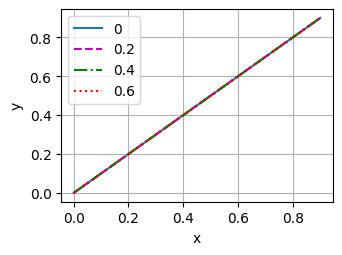

In [ ]:
alphas = [0, .2, .4, .6, .8, 1]
x = torch.arange(-2, 1, 0.1)
Y = [nn.ReLU(alpha)(x).detach().numpy() for alpha in alphas]#aici-------------------------------------------------------------
plot(x.detach().numpy(), Y, 'x', 'y', alphas)

In [ ]:
class D_block(nn.Module):
    def __init__(self, out_channels, in_channels=3, kernel_size=4, strides=2,
                padding=1, alpha=0.2, **kwargs):
        super(D_block, self).__init__(**kwargs)
        self.conv2d = nn.Conv2d(in_channels, out_channels, kernel_size,
                                strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        #self.activation = nn.LeakyReLU(alpha, inplace=True)
        self.activation = nn.ReLU()#aici-------------------------------------------------------------------

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d(X)))

In [ ]:
x = torch.zeros((2, 3, 16, 16))
d_blk = D_block(20)
d_blk(x).shape

torch.Size([2, 20, 8, 8])

In [ ]:
n_D = 64
net_D = nn.Sequential(
    D_block(n_D),  # Output: (64, 32, 32)
    D_block(in_channels=n_D, out_channels=n_D*2),  # Output: (64 * 2, 16, 16)
    D_block(in_channels=n_D*2, out_channels=n_D*4),  # Output: (64 * 4, 8, 8)
    D_block(in_channels=n_D*4, out_channels=n_D*8),  # Output: (64 * 8, 4, 4)
    nn.Conv2d(in_channels=n_D*8, out_channels=1,
              kernel_size=4, bias=False))  # Output: (1, 1, 1)

In [ ]:
x = torch.zeros((1, 3, 64, 64))
net_D(x).shape

torch.Size([1, 1, 1, 1])

In [ ]:
def train(net_D, net_G, data_iter, num_epochs, lr, latent_dim,
          device=try_gpu()):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)
    net_D, net_G = net_D.to(device), net_G.to(device)
    trainer_hp = {'lr': lr, 'betas': [0.5,0.999]}
    trainer_D = torch.optim.Adam(net_D.parameters(), **trainer_hp)
    trainer_G = torch.optim.Adam(net_G.parameters(), **trainer_hp)
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.3)
    D_loss = 0
    G_loss = 0
    total_examples = 0
    for epoch in range(1, num_epochs + 1):
        # Train one epoch
        for X, _ in data_iter:
            batch_size = X.shape[0]
            Z = torch.normal(0, 1, size=(batch_size, latent_dim, 1, 1))
            X, Z = X.to(device), Z.to(device)
            D_loss += update_D(X, Z, net_D, net_G, loss, trainer_D)
            G_loss += update_G(Z, net_D, net_G, loss, trainer_G)
            total_examples += batch_size
        # Show generated examples
        Z = torch.normal(0, 1, size=(21, latent_dim, 1, 1), device=device)
        # Normalize the synthetic data to N(0, 1)
        fake_x = net_G(Z).permute(0, 2, 3, 1) / 2 + 0.5
        imgs = torch.cat(
            [torch.cat([
                fake_x[i * 7 + j].cpu().detach() for j in range(7)], dim=1)
             for i in range(len(fake_x)//7)], dim=0)
        animator.axes[1].cla()
        animator.axes[1].imshow(imgs)
        # Show the losses
        loss_D, loss_G = D_loss / total_examples, G_loss / total_examples
        animator.add(epoch, (loss_D.cpu().detach().numpy(), loss_G.cpu().detach().numpy()))
    print(f'loss_D {loss_D:.3f}, loss_G {loss_G:.3f}, ')

loss_D 0.503, loss_G 2.346, 


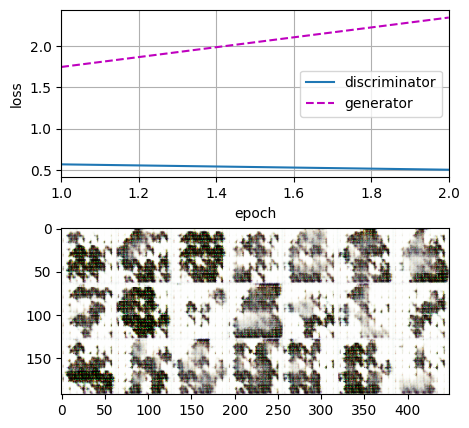

In [ ]:
latent_dim, lr, num_epochs = 100, 0.005, 2 #3 min
train(net_D, net_G, data_iter, num_epochs, lr, latent_dim)

Exercitiul 2

2. Apply DCGAN on Fashion-MNIST and see which category works well and which does not.

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/pokemon.zip', 'pokemon')
pokemon = torchvision.datasets.ImageFolder(data_dir)

In [ ]:
batch_size = 256
transformer = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)
])
pokemon.transform = transformer
data_iter = torch.utils.data.DataLoader(
    pokemon, batch_size=batch_size,
    shuffle=True, num_workers=2)

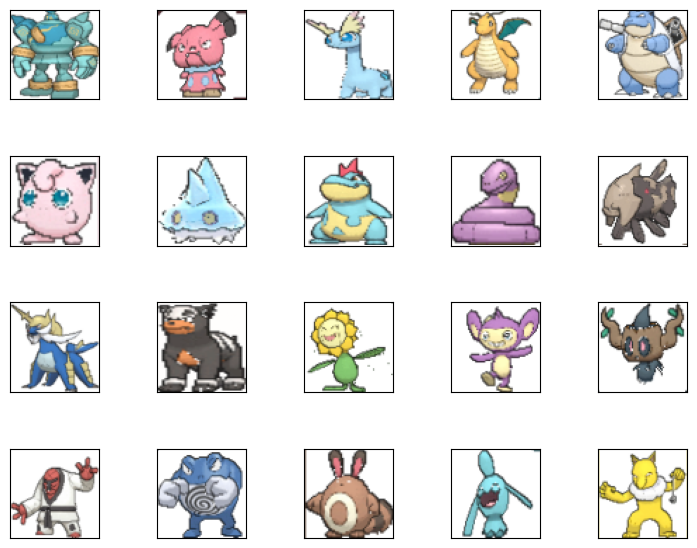

In [ ]:
warnings.filterwarnings('ignore')
set_figsize((4, 4))
for X, y in data_iter:
    imgs = X[:20,:,:,:].permute(0, 2, 3, 1)/2+0.5
    show_images(imgs, num_rows=4, num_cols=5)
    break

In [ ]:
class G_block(nn.Module):
    def __init__(self, out_channels, in_channels=1, kernel_size=4, strides=2,#aici----------------------------------------------------1
                 padding=1, **kwargs):
        super(G_block, self).__init__(**kwargs)
        self.conv2d_trans = nn.ConvTranspose2d(in_channels, out_channels,
                                kernel_size, strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU()

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d_trans(X)))

In [ ]:
x = torch.zeros((2, 1, 16, 16))#aici
g_blk = G_block(20)
g_blk(x).shape

torch.Size([2, 20, 32, 32])

In [ ]:
x = torch.zeros((2, 1, 1, 1))#aici
g_blk = G_block(20, strides=1, padding=0)
g_blk(x).shape

torch.Size([2, 20, 4, 4])

In [ ]:
n_G = 64
net_G = nn.Sequential(
    G_block(in_channels=100, out_channels=n_G*8,
            strides=1, padding=0),                  # Output: (64 * 8, 4, 4)
    G_block(in_channels=n_G*8, out_channels=n_G*4), # Output: (64 * 4, 8, 8)
    G_block(in_channels=n_G*4, out_channels=n_G*2), # Output: (64 * 2, 16, 16)
    G_block(in_channels=n_G*2, out_channels=n_G),   # Output: (64, 32, 32)
    nn.ConvTranspose2d(in_channels=n_G, out_channels=1,#aici--------------------------------------
                       kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh())  # Output: (3, 64, 64)

In [ ]:
x = torch.zeros((1, 100, 1, 1))
net_G(x).shape

torch.Size([1, 1, 64, 64])

In [ ]:
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

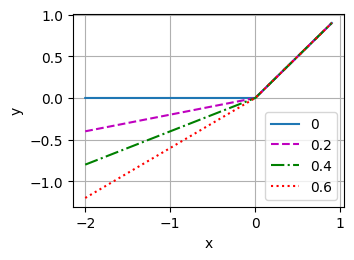

In [ ]:
alphas = [0, .2, .4, .6, .8, 1]
x = torch.arange(-2, 1, 0.1)
Y = [nn.LeakyReLU(alpha)(x).detach().numpy() for alpha in alphas]
plot(x.detach().numpy(), Y, 'x', 'y', alphas)

In [ ]:
class D_block(nn.Module):
    def __init__(self, out_channels, in_channels=1, kernel_size=4, strides=2,#aici trebuie 1 la in_channels
                padding=1, alpha=0.2, **kwargs):
        super(D_block, self).__init__(**kwargs)
        self.conv2d = nn.Conv2d(in_channels, out_channels, kernel_size,
                                strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(alpha, inplace=True)

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d(X)))

In [ ]:
x = torch.zeros((2, 1, 16, 16))#aici----------------------------------------------------------------------------1
d_blk = D_block(20)
d_blk(x).shape

torch.Size([2, 20, 8, 8])

In [ ]:
n_D = 64
net_D = nn.Sequential(
    D_block(n_D),  # Output: (64, 32, 32)
    D_block(in_channels=n_D, out_channels=n_D*2),  # Output: (64 * 2, 16, 16)
    D_block(in_channels=n_D*2, out_channels=n_D*4),  # Output: (64 * 4, 8, 8)
    D_block(in_channels=n_D*4, out_channels=n_D*8),  # Output: (64 * 8, 4, 4)
    nn.Conv2d(in_channels=n_D*8, out_channels=1,
              kernel_size=4, bias=False))  # Output: (1, 1, 1)

In [ ]:
x = torch.zeros((1, 1, 64, 64))#aici--------------------------1 pt al doilea parametru
net_D(x).shape

torch.Size([1, 1, 1, 1])

In [ ]:
def train(net_D, net_G, data_iter, num_epochs, lr, latent_dim,
          device=try_gpu()):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)
    net_D, net_G = net_D.to(device), net_G.to(device)
    trainer_hp = {'lr': lr, 'betas': [0.5,0.999]}
    trainer_D = torch.optim.Adam(net_D.parameters(), **trainer_hp)
    trainer_G = torch.optim.Adam(net_G.parameters(), **trainer_hp)
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.3)
    D_loss = 0
    G_loss = 0
    total_examples = 0
    for epoch in range(1, num_epochs + 1):
        # Train one epoch
        for X, _ in data_iter:
            batch_size = X.shape[0]
            Z = torch.normal(0, 1, size=(batch_size, latent_dim, 1, 1))
            X, Z = X.to(device), Z.to(device)
            D_loss += update_D(X, Z, net_D, net_G, loss, trainer_D)
            G_loss += update_G(Z, net_D, net_G, loss, trainer_G)
            total_examples += batch_size
        # Show generated examples
        Z = torch.normal(0, 1, size=(21, latent_dim, 1, 1), device=device)
        # Normalize the synthetic data to N(0, 1)
        fake_x = net_G(Z).permute(0, 2, 3, 1) / 2 + 0.5
        imgs = torch.cat(
            [torch.cat([
                fake_x[i * 7 + j].cpu().detach() for j in range(7)], dim=1)
             for i in range(len(fake_x)//7)], dim=0)
        animator.axes[1].cla()
        animator.axes[1].imshow(imgs)
        # Show the losses
        loss_D, loss_G = D_loss / total_examples, G_loss / total_examples
        animator.add(epoch, (loss_D.cpu().detach().numpy(), loss_G.cpu().detach().numpy()))
    print(f'loss_D {loss_D:.3f}, loss_G {loss_G:.3f}, ')

In [ ]:
import torchvision
from torchvision import transforms

# `ToTensor()` converts the image data from PIL type to 32-bit floating point
# tensors. It also divides all numbers by 255, so that all pixel values are between
# 0 and 1
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

In [ ]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [50000, 10000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
train_iter, val_iter, test_iter = load_data_fashion_mnist(batch_size,resize=64)#aici trebuie dat un resize la 64 pt a nu da eroare

loss_D 0.369, loss_G 3.091, 


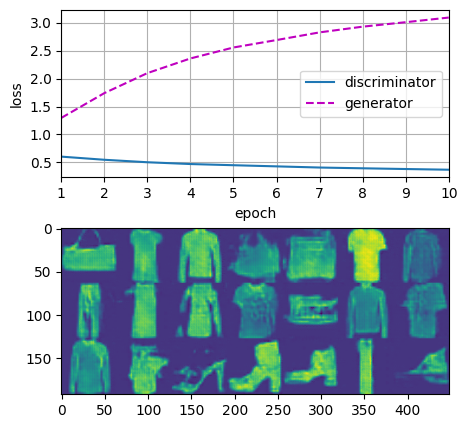

In [ ]:
latent_dim, lr, num_epochs = 100, 0.002, 10 #3 min - 11 min pt modficari
train(net_D, net_G, train_iter, num_epochs, lr, latent_dim)

#Laboratorul 11

Exercitiul 1

1. Implement ResNet3D-18 from scratch starting from the implementation of ResNet in Laboratory 4.

In [1]:
!pip install av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 15.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import random_split, DataLoader
from torch.optim.lr_scheduler import StepLR
import torchvision
from torchvision.models.video import r3d_18
from torchvision import transforms
import os
import warnings

torch.manual_seed(42);

warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!mkdir -p video_data test_train_splits
!unrar e 'drive/MyDrive/test_train_splits.rar' test_train_splits # Provide the proper path location
!unrar e 'drive/MyDrive/hmdb51_org.rar' video_data # Provide the proper path location

for files in os.listdir('video_data'):
    foldername = files.split('.')[0]
    os.system("mkdir -p video_data/" + foldername)
    os.system("unrar e video_data/"+ files + " video_data/" + foldername)
!rm video_data/*.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from drive/MyDrive/test_train_splits.rar

Extracting  test_train_splits/brush_hair_test_split1.txt                   0%  OK 
Extracting  test_train_splits/brush_hair_test_split2.txt                   1%  OK 
Extracting  test_train_splits/brush_hair_test_split3.txt                   1%  OK 
Extracting  test_train_splits/cartwheel_test_split1.txt                    2%  OK 
Extracting  test_train_splits/cartwheel_test_split2.txt                    2%  OK 
Extracting  test_train_splits/cartwheel_test_split3.txt                    3%  OK 
Extracting  test_train_splits/catch_test_split1.txt                        4%  OK 
Extracting  test_train_splits/catch_test_split2.txt                        4%  OK 
Extracting  test_train_splits/catch_test_split3.txt                        5%  OK 
Extracting  test_train_splits/chew_test_spl

In [5]:
val_split = 0.05 #3 min
num_frames = 16
clip_steps = 50
num_workers = 8
bs = 4

train_tfms = torchvision.transforms.Compose([
                                 transforms.Lambda(lambda x: x.permute(3, 0, 1, 2).to(torch.float32) / 255.),
                                 transforms.Resize((128, 171)),
                                 transforms.RandomHorizontalFlip(),
                                 transforms.RandomCrop((112, 112))
                               ])
test_tfms = torchvision.transforms.Compose([
                                             transforms.Lambda(lambda x: x.permute(3, 0, 1, 2).to(torch.float32) / 255.),
                                             transforms.Resize((128, 171)),
                                             transforms.CenterCrop((112, 112))
                                             ])

hmdb51_train = torchvision.datasets.HMDB51('video_data/', 'test_train_splits/', num_frames,
                                                step_between_clips=clip_steps, fold=1, train=True,
                                                transform=train_tfms, num_workers=num_workers)

hmdb51_test = torchvision.datasets.HMDB51('video_data/', 'test_train_splits/', num_frames,
                                                step_between_clips=clip_steps, fold=1, train=False,
                                                transform=test_tfms, num_workers=num_workers)


total_train_samples = len(hmdb51_train)
total_val_samples = round(val_split * total_train_samples)

hmdb51_train_v1, hmdb51_val_v1 = random_split(hmdb51_train, [total_train_samples - total_val_samples, total_val_samples])

train_loader = DataLoader(hmdb51_train_v1, batch_size=bs, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(hmdb51_val_v1, batch_size=bs, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(hmdb51_test, batch_size=bs, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"number of train samples {total_train_samples - total_val_samples}")
print(f"number of validation samples {total_val_samples}")
print(f"number of test samples {len(hmdb51_test)}")

100%|██████████| 423/423 [01:43<00:00,  4.08it/s]


number of train samples 7366
number of validation samples 388
number of test samples 3234


In [6]:
class VideoRecognitionModel(nn.Module):
  def __init__(self):
      super(VideoRecognitionModel, self).__init__()
      self.base_model = nn.Sequential(*list(r3d_18().children())[:-1])
      self.fc = nn.Linear(512, 51)

  def forward(self, x):
      out = self.base_model(x).flatten(1)
      out = F.relu(self.fc(out))
      return out

In [7]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [8]:
def train(model, loader, optimizer, epoch, device=try_gpu()):
    model.train()
    model = model.to(device)
    total_loss, total_correct, num_labels = 0, 0, 0
    for batch_id, data in enumerate(loader):
        data, target = data[0], data[-1]

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_labels += data.size(0)

        pred = output.argmax(dim=1, keepdim=True)  # get the index of the max probability
        num_corrects = pred.eq(target.view_as(pred)).sum().item()

        total_correct += num_corrects

        if (batch_id + 1) % 100 == 0:
           print('Train Epoch: {} Batch [{}/{} ({:.0f}%)]\tLoss: {:.6f} Accuracy: {}/{} ({:.0f}%)'.format(
                epoch, (batch_id + 1) * len(data), len(loader.dataset),
                100. * (batch_id + 1) / len(loader), total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

    print('Train Epoch: {} Average Loss: {:.6f} Average Accuracy: {}/{} ({:.0f}%)'.format(
         epoch, total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

In [9]:
def test(model, loader, text='Validation', device=try_gpu()):
    model.eval()
    model = model.to(device)
    total_loss, total_correct, num_labels = 0, 0, 0
    with torch.no_grad():
         for batch_id, data in enumerate(loader):
             data, target = data[0], data[-1]

             data = data.to(device)
             target = target.to(device)

             output = model(data)
             loss = F.cross_entropy(output, target)

             total_loss += loss.item()
             num_labels += data.size(0)

             pred = output.argmax(dim=1, keepdim=True)  # get the index of the max probability
             num_corrects = pred.eq(target.view_as(pred)).sum().item()

             total_correct += num_corrects

    print(text + ' Average Loss: {:.6f} Average Accuracy: {}/{} ({:.0f}%)'.format(
         total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

In [10]:
lr = 1e-2 #9 min
gamma = 0.7
total_epochs = 1

model = VideoRecognitionModel()

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, total_epochs + 1):
    train(model, train_loader, optimizer, epoch)
    test(model, val_loader, text="Validation")
    scheduler.step()

Train Epoch: 1 Batch [400/7366 (5%)]	Loss: 0.991508 Accuracy: 14/400 (4%)
Train Epoch: 1 Batch [800/7366 (11%)]	Loss: 0.987232 Accuracy: 32/800 (4%)
Train Epoch: 1 Batch [1200/7366 (16%)]	Loss: 0.985807 Accuracy: 52/1200 (4%)
Train Epoch: 1 Batch [1600/7366 (22%)]	Loss: 0.985094 Accuracy: 69/1600 (4%)
Train Epoch: 1 Batch [2000/7366 (27%)]	Loss: 0.984667 Accuracy: 94/2000 (5%)
Train Epoch: 1 Batch [2400/7366 (33%)]	Loss: 0.984382 Accuracy: 115/2400 (5%)
Train Epoch: 1 Batch [2800/7366 (38%)]	Loss: 0.984178 Accuracy: 137/2800 (5%)
Train Epoch: 1 Batch [3200/7366 (43%)]	Loss: 0.984025 Accuracy: 158/3200 (5%)
Train Epoch: 1 Batch [3600/7366 (49%)]	Loss: 0.983907 Accuracy: 175/3600 (5%)
Train Epoch: 1 Batch [4000/7366 (54%)]	Loss: 0.983812 Accuracy: 188/4000 (5%)
Train Epoch: 1 Batch [4400/7366 (60%)]	Loss: 0.983734 Accuracy: 207/4400 (5%)
Train Epoch: 1 Batch [4800/7366 (65%)]	Loss: 0.983669 Accuracy: 228/4800 (5%)
Train Epoch: 1 Batch [5200/7366 (71%)]	Loss: 0.983614 Accuracy: 245/5200 (

In [11]:
test(model, test_loader, text="Test") #2 min

Test Average Loss: 0.983564 Average Accuracy: 179/3234 (6%)


# cu ResNet3D-18

In [16]:
class Residual(nn.Module):
    """The Residual block of ResNet."""
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv3d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.bn1 = nn.BatchNorm3d(num_channels)
        self.conv2 = nn.Conv3d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(num_channels)
        if use_1x1conv:
            self.conv3 = nn.Conv3d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        Y = nn.ReLU()(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return nn.ReLU()(Y)

b1 = nn.Sequential(nn.Conv3d(3, 64, kernel_size=7, stride=2, padding=3),#avem trei canale. atentie ii 3d inlocuim unde ii 2d
                   nn.BatchNorm3d(64), nn.ReLU(),
                   nn.MaxPool3d(kernel_size=3, stride=2, padding=1))

def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))


net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool3d((1, 1, 1)),#aici am mai adaugat un 1 pt ca ii 3d poolingul
                    nn.Flatten(), nn.Linear(512, 51))
'''
Cele 51 de ieșiri (output-uri) ale stratului liniar (nn.Linear) corespund celor 51 de categorii de acțiuni din setul de date HMDB51.
Acesta este un model de clasificare, iar numărul de neuroni din ultimul strat liniar este întotdeauna egal cu numărul de clase pe care
modelul trebuie să le distingă.
'''
net

Sequential(
  (0): Sequential(
    (0): Conv3d(3, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): Residual(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Residual(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1

In [17]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [18]:
def train(model, loader, optimizer, epoch, device=try_gpu()):
    model.train()
    model = model.to(device)
    total_loss, total_correct, num_labels = 0, 0, 0
    for batch_id, data in enumerate(loader):
        data, target = data[0], data[-1]

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_labels += data.size(0)

        pred = output.argmax(dim=1, keepdim=True)  # get the index of the max probability
        num_corrects = pred.eq(target.view_as(pred)).sum().item()

        total_correct += num_corrects

        if (batch_id + 1) % 100 == 0:
           print('Train Epoch: {} Batch [{}/{} ({:.0f}%)]\tLoss: {:.6f} Accuracy: {}/{} ({:.0f}%)'.format(
                epoch, (batch_id + 1) * len(data), len(loader.dataset),
                100. * (batch_id + 1) / len(loader), total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

    print('Train Epoch: {} Average Loss: {:.6f} Average Accuracy: {}/{} ({:.0f}%)'.format(
         epoch, total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

In [19]:
def test(model, loader, text='Validation', device=try_gpu()):
    model.eval()
    model = model.to(device)
    total_loss, total_correct, num_labels = 0, 0, 0
    with torch.no_grad():
         for batch_id, data in enumerate(loader):
             data, target = data[0], data[-1]

             data = data.to(device)
             target = target.to(device)

             output = model(data)
             loss = F.cross_entropy(output, target)

             total_loss += loss.item()
             num_labels += data.size(0)

             pred = output.argmax(dim=1, keepdim=True)  # get the index of the max probability
             num_corrects = pred.eq(target.view_as(pred)).sum().item()

             total_correct += num_corrects

    print(text + ' Average Loss: {:.6f} Average Accuracy: {}/{} ({:.0f}%)'.format(
         total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

In [20]:
lr = 1e-2 #9 min
gamma = 0.7
total_epochs = 1

#model = VideoRecognitionModel()
model = net

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, total_epochs + 1):
    train(model, train_loader, optimizer, epoch)
    test(model, val_loader, text="Validation")
    scheduler.step()

Train Epoch: 1 Batch [400/7366 (5%)]	Loss: 1.215927 Accuracy: 11/400 (3%)
Train Epoch: 1 Batch [800/7366 (11%)]	Loss: 1.101119 Accuracy: 27/800 (3%)
Train Epoch: 1 Batch [1200/7366 (16%)]	Loss: 1.058935 Accuracy: 48/1200 (4%)
Train Epoch: 1 Batch [1600/7366 (22%)]	Loss: 1.036103 Accuracy: 77/1600 (5%)
Train Epoch: 1 Batch [2000/7366 (27%)]	Loss: 1.023371 Accuracy: 102/2000 (5%)
Train Epoch: 1 Batch [2400/7366 (33%)]	Loss: 1.014298 Accuracy: 120/2400 (5%)
Train Epoch: 1 Batch [2800/7366 (38%)]	Loss: 1.008713 Accuracy: 136/2800 (5%)
Train Epoch: 1 Batch [3200/7366 (43%)]	Loss: 1.003628 Accuracy: 158/3200 (5%)
Train Epoch: 1 Batch [3600/7366 (49%)]	Loss: 0.999536 Accuracy: 176/3600 (5%)
Train Epoch: 1 Batch [4000/7366 (54%)]	Loss: 0.995687 Accuracy: 196/4000 (5%)
Train Epoch: 1 Batch [4400/7366 (60%)]	Loss: 0.992446 Accuracy: 223/4400 (5%)
Train Epoch: 1 Batch [4800/7366 (65%)]	Loss: 0.990379 Accuracy: 244/4800 (5%)
Train Epoch: 1 Batch [5200/7366 (71%)]	Loss: 0.988678 Accuracy: 259/5200 

In [21]:
test(model, test_loader, text="Test") #2 min

Test Average Loss: 0.968469 Average Accuracy: 179/3234 (6%)


#Exercitiul 2

Replace the ResNet3D-18 model with the C3D model given in Figure 8, Lecture 9, and compare their performance.

In [22]:
import torch
from torch import nn
import torch.nn.functional as F

class C3D(nn.Module):
  def __init__(self, num_classes=51, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=3,padding=1),#conv1a
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2)), #pool1

            nn.Conv3d(64,128, kernel_size=3,padding=1),#conv2a
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)), #pool2

            nn.Conv3d(128,256, kernel_size=3,padding=1),#conv3a
            nn.ReLU(inplace=True),
            nn.Conv3d(256,256, kernel_size=3,padding=1),#conv3b
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)), #pool3

            nn.Conv3d(256,512, kernel_size=3,padding=1),#conv4a
            nn.ReLU(inplace=True),
            nn.Conv3d(512,512, kernel_size=3,padding=1),#conv4b
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)), #pool4

            nn.Conv3d(512,512, kernel_size=3,padding=1),#conv5a
            nn.ReLU(inplace=True),
            nn.Conv3d(512,512, kernel_size=3,padding=1),#conv5b
            nn.ReLU(inplace=True),

            # pool5 (standard C3D folosește padding (0,1,1) ca să ajungă la 4x4 pe 112x112)
            nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2),padding=(0,1,1)) #pool5
        )

        self.fc6 = nn.Linear(8192, 4096)
        self.fc7 = nn.Linear(4096, 4096)
        self.fc8 = nn.Linear(4096, num_classes)
        self.dropout = nn.Dropout(dropout)

  def forward(self,x):
      x = self.features(x)
      x = x.flatten(1)
      x = self.dropout(F.relu(self.fc6(x)))
      x = self.dropout(F.relu(self.fc7(x)))
      x = self.fc8(x)
      return x

In [23]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [24]:
def train(model, loader, optimizer, epoch, device=try_gpu()):
    model.train()
    model = model.to(device)
    total_loss, total_correct, num_labels = 0, 0, 0
    for batch_id, data in enumerate(loader):
        data, target = data[0], data[-1]

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_labels += data.size(0)

        pred = output.argmax(dim=1, keepdim=True)  # get the index of the max probability
        num_corrects = pred.eq(target.view_as(pred)).sum().item()

        total_correct += num_corrects

        if (batch_id + 1) % 100 == 0:
           print('Train Epoch: {} Batch [{}/{} ({:.0f}%)]\tLoss: {:.6f} Accuracy: {}/{} ({:.0f}%)'.format(
                epoch, (batch_id + 1) * len(data), len(loader.dataset),
                100. * (batch_id + 1) / len(loader), total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

    print('Train Epoch: {} Average Loss: {:.6f} Average Accuracy: {}/{} ({:.0f}%)'.format(
         epoch, total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

In [25]:
def test(model, loader, text='Validation', device=try_gpu()):
    model.eval()
    model = model.to(device)
    total_loss, total_correct, num_labels = 0, 0, 0
    with torch.no_grad():
         for batch_id, data in enumerate(loader):
             data, target = data[0], data[-1]

             data = data.to(device)
             target = target.to(device)

             output = model(data)
             loss = F.cross_entropy(output, target)

             total_loss += loss.item()
             num_labels += data.size(0)

             pred = output.argmax(dim=1, keepdim=True)  # get the index of the max probability
             num_corrects = pred.eq(target.view_as(pred)).sum().item()

             total_correct += num_corrects

    print(text + ' Average Loss: {:.6f} Average Accuracy: {}/{} ({:.0f}%)'.format(
         total_loss / num_labels, total_correct, num_labels, 100. * total_correct / num_labels))

In [26]:
lr = 1e-2 #9 min
gamma = 0.7
total_epochs = 1

model = C3D()

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, total_epochs + 1):
    train(model, train_loader, optimizer, epoch)
    test(model, val_loader, text="Validation")
    scheduler.step()

Train Epoch: 1 Batch [400/7366 (5%)]	Loss: 272945070.992350 Accuracy: 14/400 (4%)
Train Epoch: 1 Batch [800/7366 (11%)]	Loss: 136472614.268384 Accuracy: 22/800 (3%)
Train Epoch: 1 Batch [1200/7366 (16%)]	Loss: 90981743.187810 Accuracy: 32/1200 (3%)
Train Epoch: 1 Batch [1600/7366 (22%)]	Loss: 68236307.639577 Accuracy: 45/1600 (3%)
Train Epoch: 1 Batch [2000/7366 (27%)]	Loss: 54589046.309236 Accuracy: 65/2000 (3%)
Train Epoch: 1 Batch [2400/7366 (33%)]	Loss: 45490872.087675 Accuracy: 84/2400 (4%)
Train Epoch: 1 Batch [2800/7366 (38%)]	Loss: 38992176.214538 Accuracy: 113/2800 (4%)
Train Epoch: 1 Batch [3200/7366 (43%)]	Loss: 34118154.309324 Accuracy: 134/3200 (4%)
Train Epoch: 1 Batch [3600/7366 (49%)]	Loss: 30327316.386718 Accuracy: 148/3600 (4%)
Train Epoch: 1 Batch [4000/7366 (54%)]	Loss: 27294587.467463 Accuracy: 155/4000 (4%)
Train Epoch: 1 Batch [4400/7366 (60%)]	Loss: 24813261.750637 Accuracy: 170/4400 (4%)
Train Epoch: 1 Batch [4800/7366 (65%)]	Loss: 22745490.132317 Accuracy: 197

In [27]:
test(model, test_loader, text="Test") #2 min

Test Average Loss: 0.970341 Average Accuracy: 179/3234 (6%)
